✅ Running di Google Colab

SILAKAN UPLOAD FILE DATA PENELITIAN

📂 Upload Pre-Test (Clean_KuesionerPreTest - Sheet 1.csv):


Saving Clean_KuesionerPreTest - Sheet 1.csv to Clean_KuesionerPreTest - Sheet 1 (4).csv

📂 Upload Post-Test (Clean_KuesionerPostTest - Sheet 1.csv):


Saving Clean_KuesionerPostTest - Sheet 1.csv to Clean_KuesionerPostTest - Sheet 1 (4).csv
✅ Pre-Test  : 197 responden
✅ Post-Test : 197 responden

STRUKTUR KOLOM

📋 Pre-Test columns:
  - Asal Sekolah
  - Kelas
  - Jurusan
  - KODE_RESPONDEN
  - P1
  - P2
  - P3
  - P4
  - P5
  - P6
  - P7
  - P8

📋 Post-Test columns:
  - Asal Sekolah
  - Kelas
  - Jurusan
  - KODE_RESPONDEN
  - A1
  - A2
  - A3
  - A4
  - A5
  - A6
  - A7
  - A8
  - B1
  - B2
  - B3
  - B4
  - B5
  - B6
  - C1
  - C2
  - C3
  - C4
  - C5
  - C6
  - C7

📊 Merge berdasarkan: KODE_RESPONDEN

✅ Pre-Test questions  : 8 (P1-P8)
✅ Post-Test A         : 8 (A1-A8) - Pemahaman
✅ Post-Test B         : 6 (B1-B6) - Visual/Audio
✅ Post-Test C         : 7 (C1-C7) - Isi/Penyampaian

🔗 Setelah merge: 197 responden
   Responden hanya di Pre-Test : 0
   Responden hanya di Post-Test: 0

A. STATISTIK DESKRIPTIF

                        Aspek   N      Mean       Std       Min  Max
                     Pre-Test 197 46.837563  9.772097  8.000

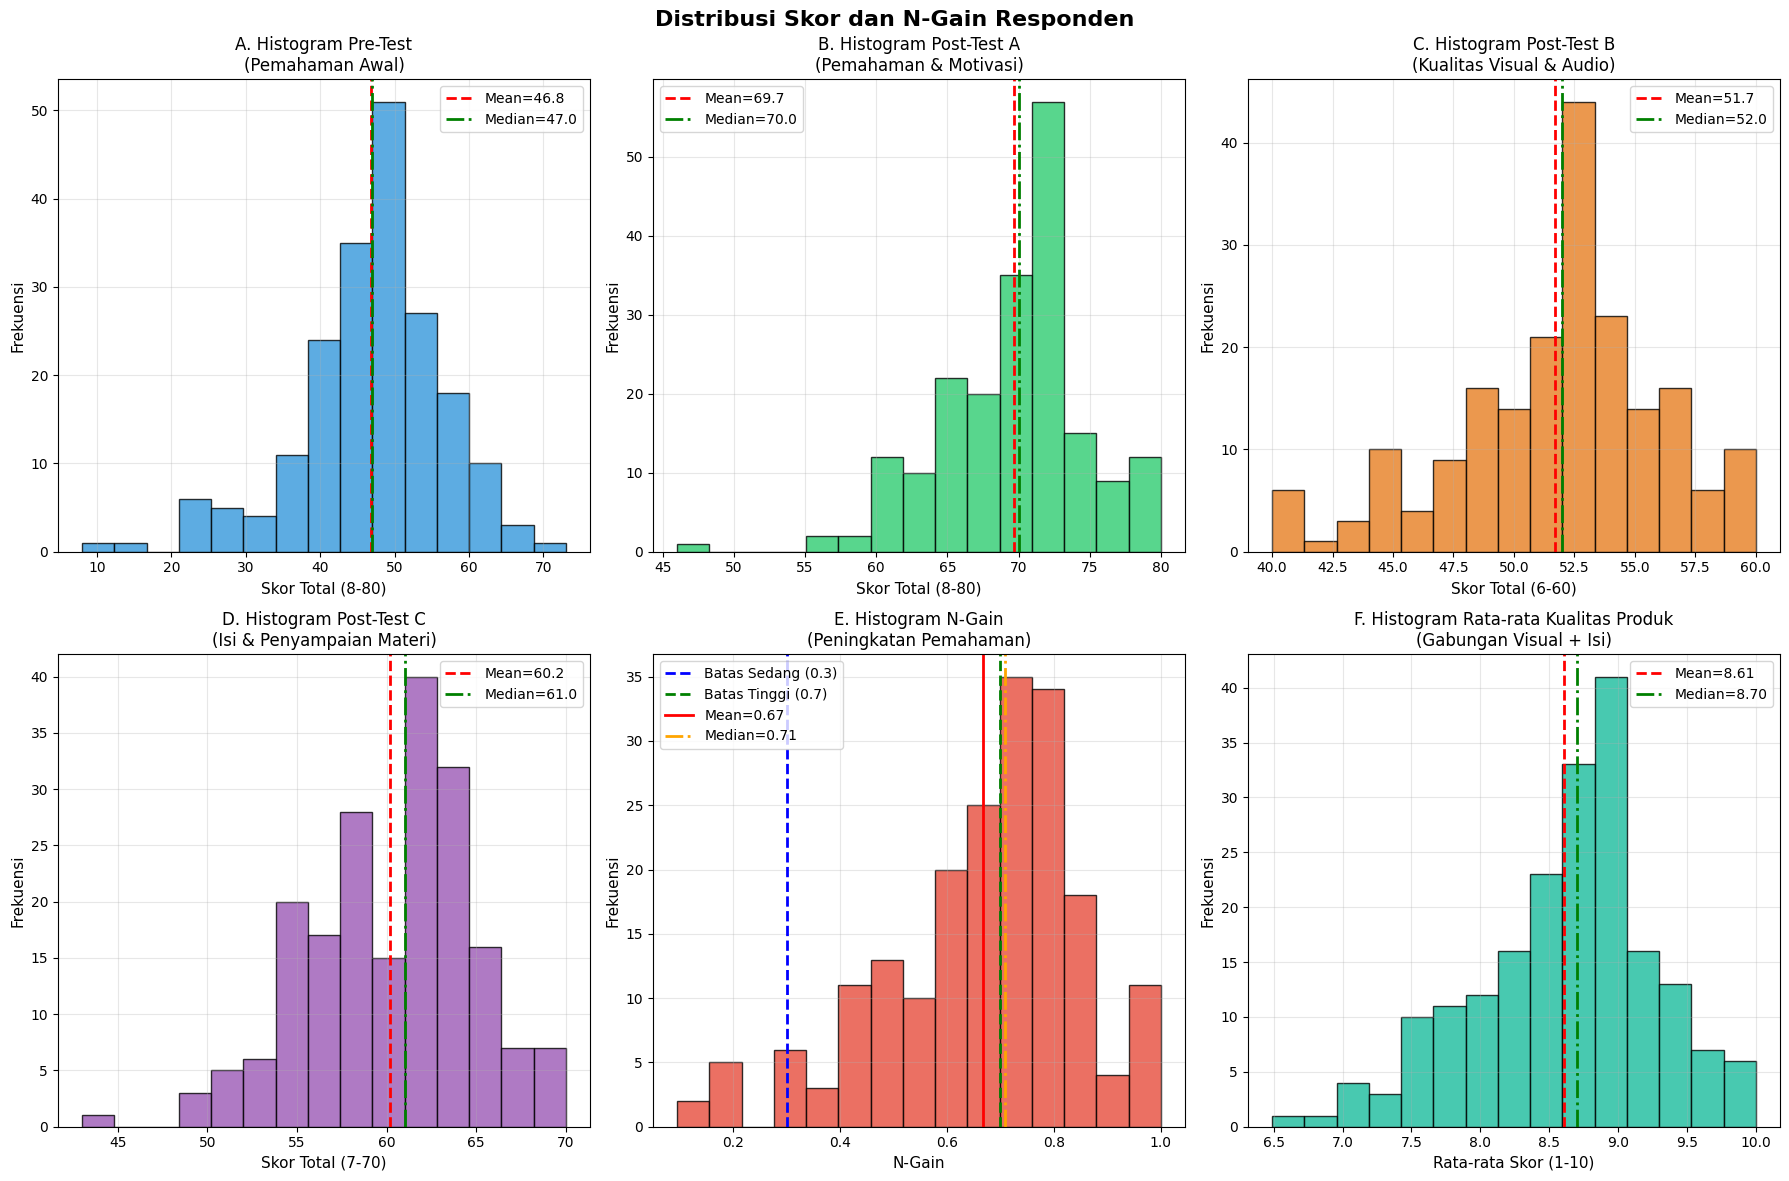


✅ Histogram disimpan sebagai 'histogram_semua_aspek.png'

E. PERBANDINGAN PRE-TEST VS POST-TEST PER ITEM

Item  Pre-Test Mean  Post-Test Mean    Delta
  P1       6.167513        8.888325 2.720812
  P2       5.791878        8.680203 2.888325
  P3       5.898477        8.771574 2.873096
  P4       5.868020        8.690355 2.822335
  P5       5.969543        8.695431 2.725888
  P6       5.771574        8.634518 2.862944
  P7       5.659898        8.725888 3.065990
  P8       5.710660        8.598985 2.888325

📈 Rata-rata peningkatan per item: 2.856

📈 Item dengan peningkatan tertinggi: P7 (Δ = 3.066)
📈 Item dengan peningkatan terendah : P1 (Δ = 2.721)


In [14]:
# ============================================================
# ANALISIS DATA OPSI 2026
# Sistem Optimasi Prompt Multi-Kriteria pada Generative AI
# Fokus: Efektivitas Modul (Pre-Post Test) & Reliabilitas Instrumen
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# --- CEK APAKAH DI GOOGLE COLAB ---
try:
    from google.colab import files
    IN_COLAB = True
    print("✅ Running di Google Colab")
except:
    IN_COLAB = False
    print("ℹ️ Running di Local Environment")

# --- 1. UPLOAD DATA ---
if IN_COLAB:
    print("\n" + "="*60)
    print("SILAKAN UPLOAD FILE DATA PENELITIAN")
    print("="*60)

    print("\n📂 Upload Pre-Test (Clean_KuesionerPreTest - Sheet 1.csv):")
    uploaded_pre = files.upload()

    print("\n📂 Upload Post-Test (Clean_KuesionerPostTest - Sheet 1.csv):")
    uploaded_post = files.upload()

    pre_filename = list(uploaded_pre.keys())[0]
    post_filename = list(uploaded_post.keys())[0]
else:
    import os
    pre_filename = 'Clean_KuesionerPreTest - Sheet 1.csv'
    post_filename = 'Clean_KuesionerPostTest - Sheet 1.csv'

    if not os.path.exists(pre_filename) or not os.path.exists(post_filename):
        print("\n❌ File tidak ditemukan!")
        exit()

# --- 2. LOAD DATA ---
pre = pd.read_csv(pre_filename)
post = pd.read_csv(post_filename)

print(f"✅ Pre-Test  : {len(pre)} responden")
print(f"✅ Post-Test : {len(post)} responden")

# --- 3. CEK STRUKTUR KOLOM ---
print("\n" + "="*60)
print("STRUKTUR KOLOM")
print("="*60)

print("\n📋 Pre-Test columns:")
for col in pre.columns:
    print(f"  - {col}")

print("\n📋 Post-Test columns:")
for col in post.columns:
    print(f"  - {col}")

# --- 4. IDENTIFIKASI KOLOM ---

# 4a. Kolom identitas untuk merge
merge_col = 'KODE_RESPONDEN'
print(f"\n📊 Merge berdasarkan: {merge_col}")

# 4b. Kolom pertanyaan Pre-Test (P1-P8)
pre_q_cols = ['P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8']

# 4c. Kolom pertanyaan Post-Test
post_A_cols = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8']  # Pemahaman
post_B_cols = ['B1', 'B2', 'B3', 'B4', 'B5', 'B6']              # Visual/Audio
post_C_cols = ['C1', 'C2', 'C3', 'C4', 'C5', 'C6', 'C7']        # Isi/Penyampaian

print(f"\n✅ Pre-Test questions  : {len(pre_q_cols)} (P1-P8)")
print(f"✅ Post-Test A         : {len(post_A_cols)} (A1-A8) - Pemahaman")
print(f"✅ Post-Test B         : {len(post_B_cols)} (B1-B6) - Visual/Audio")
print(f"✅ Post-Test C         : {len(post_C_cols)} (C1-C7) - Isi/Penyampaian")

# --- 5. MERGE DATA ---
merged = pd.merge(pre, post, on=merge_col, how='inner')
print(f"\n🔗 Setelah merge: {len(merged)} responden")

# Cek apakah ada data yang hilang
pre_only = set(pre[merge_col]) - set(post[merge_col])
post_only = set(post[merge_col]) - set(pre[merge_col])
print(f"   Responden hanya di Pre-Test : {len(pre_only)}")
print(f"   Responden hanya di Post-Test: {len(post_only)}")

if len(merged) == 0:
    print("\n❌ Tidak ada data yang berhasil di-merge!")
    print("   Periksa kembali file CSV Anda.")
    exit()

# --- 6. HITUNG SKOR ---
IDEAL_SCORE = 80

merged['Total_Pre'] = merged[pre_q_cols].sum(axis=1)
merged['Total_Post_A'] = merged[post_A_cols].sum(axis=1)
merged['Total_Post_B'] = merged[post_B_cols].sum(axis=1)
merged['Total_Post_C'] = merged[post_C_cols].sum(axis=1)

# --- 7. HITUNG DELTA SCORE & N-GAIN ---
merged['Delta'] = merged['Total_Post_A'] - merged['Total_Pre']
merged['N_Gain'] = (merged['Total_Post_A'] - merged['Total_Pre']) / (IDEAL_SCORE - merged['Total_Pre'])

# --- 8. HITUNG RATA-RATA KUALITAS PRODUK ---
merged['Rata_B'] = merged['Total_Post_B'] / 6
merged['Rata_C'] = merged['Total_Post_C'] / 7
merged['Rata_Kualitas'] = (merged['Rata_B'] + merged['Rata_C']) / 2

# --- 9. STATISTIK DESKRIPTIF ---
print("\n" + "="*60)
print("A. STATISTIK DESKRIPTIF")
print("="*60)

stats_summary = {
    'Aspek': ['Pre-Test', 'Post-Test A (Pemahaman)', 'Post-Test B (Visual/Audio)',
              'Post-Test C (Isi/Penyampaian)', 'Delta Score', 'N-Gain', 'Rata-rata Kualitas'],
    'N': [len(merged), len(merged), len(merged), len(merged), len(merged),
          len(merged[merged['N_Gain'].notna()]), len(merged)],
    'Mean': [merged['Total_Pre'].mean(), merged['Total_Post_A'].mean(),
             merged['Total_Post_B'].mean(), merged['Total_Post_C'].mean(),
             merged['Delta'].mean(), merged['N_Gain'].mean(), merged['Rata_Kualitas'].mean()],
    'Std': [merged['Total_Pre'].std(), merged['Total_Post_A'].std(),
            merged['Total_Post_B'].std(), merged['Total_Post_C'].std(),
            merged['Delta'].std(), merged['N_Gain'].std(), merged['Rata_Kualitas'].std()],
    'Min': [merged['Total_Pre'].min(), merged['Total_Post_A'].min(),
            merged['Total_Post_B'].min(), merged['Total_Post_C'].min(),
            merged['Delta'].min(), merged['N_Gain'].min(), merged['Rata_Kualitas'].min()],
    'Max': [merged['Total_Pre'].max(), merged['Total_Post_A'].max(),
            merged['Total_Post_B'].max(), merged['Total_Post_C'].max(),
            merged['Delta'].max(), merged['N_Gain'].max(), merged['Rata_Kualitas'].max()]
}

stats_df = pd.DataFrame(stats_summary)
print("\n" + stats_df.to_string(index=False))

# Delta score dan persentase
delta_mean = merged['Delta'].mean()
delta_percent = (merged['Total_Post_A'].mean() / merged['Total_Pre'].mean()) * 100

print(f"\n📈 Delta Score (Post - Pre)   : {delta_mean:.2f}")
print(f"📈 Persentase Peningkatan      : {delta_percent:.1f}%")

# --- 10. KATEGORI N-GAIN (Hake, 1998) ---
print("\n" + "="*60)
print("B. DISTRIBUSI KATEGORI N-GAIN")
print("="*60)

def kategorikan_ngain(x):
    if pd.isna(x):
        return 'Tidak Valid'
    elif x > 0.7:
        return 'Tinggi'
    elif x >= 0.3:
        return 'Sedang'
    else:
        return 'Rendah'

merged['Kategori_N_Gain'] = merged['N_Gain'].apply(kategorikan_ngain)

ngain_counts = merged['Kategori_N_Gain'].value_counts()
print(ngain_counts)

print("\nPersentase:")
for cat, count in ngain_counts.items():
    pct = (count / len(merged) * 100)
    print(f"  {cat}: {count} ({pct:.1f}%)")

# --- 11. UJI VALIDITAS (Spearman's Rho) ---
print("\n" + "="*60)
print("C. UJI VALIDITAS (Spearman's Rho)")
print("="*60)

def uji_validitas(df, item_cols, total_col, aspek_nama):
    print(f"\nAspek {aspek_nama}:")
    valid_count = 0
    for i, col in enumerate(item_cols, 1):
        rho, p = stats.spearmanr(df[col], df[total_col])
        valid = rho > 0.3 and p < 0.05
        status = "✓" if valid else "✗"
        if valid:
            valid_count += 1
        print(f"  Item {i}: {status} rho={rho:.3f}, p={p:.4f}")
    print(f"  Valid: {valid_count}/{len(item_cols)} item")
    return valid_count == len(item_cols)

print("\nKeterangan:")
print("  ✓ = Valid (rho > 0.3 dan p < 0.05)")
print("  ✗ = Tidak Valid")

uji_validitas(merged, pre_q_cols, 'Total_Pre', 'Pre-Test Pemahaman')
uji_validitas(merged, post_A_cols, 'Total_Post_A', 'Post-Test A (Pemahaman)')
uji_validitas(merged, post_B_cols, 'Total_Post_B', 'Post-Test B (Visual/Audio)')
uji_validitas(merged, post_C_cols, 'Total_Post_C', 'Post-Test C (Isi/Penyampaian)')

# --- 12. UJI RELIABILITAS (Cronbach's Alpha) ---
print("\n" + "="*60)
print("D. UJI RELIABILITAS (Cronbach's Alpha)")
print("="*60)

def cronbach_alpha(df, items):
    try:
        item_scores = df[items]
        item_variances = item_scores.var(axis=0, ddof=1)
        total_variance = item_scores.sum(axis=1).var(ddof=1)
        k = len(items)
        alpha = (k / (k - 1)) * (1 - (item_variances.sum() / total_variance))
        return alpha
    except:
        return np.nan

print("\nKeterangan:")
print("  ✓ Reliabel (α > 0.70)")
print("  ✗ Tidak Reliabel (α ≤ 0.70)\n")

aspek_list = [
    ('Pre-Test', pre_q_cols),
    ('Post-A (Pemahaman)', post_A_cols),
    ('Post-B (Visual/Audio)', post_B_cols),
    ('Post-C (Isi/Penyampaian)', post_C_cols)
]

reliability_results = []
for nama, cols in aspek_list:
    alpha = cronbach_alpha(merged, cols)
    status = "✓ Reliabel" if alpha > 0.7 else "✗ Tidak Reliabel"
    reliability_results.append({
        'Aspek': nama,
        'Cronbach\'s Alpha': f"{alpha:.3f}",
        'Status': status
    })
    print(f"{nama}: α = {alpha:.3f} ({status})")

print("\nTabel Ringkasan Reliabilitas:")
reliability_df = pd.DataFrame(reliability_results)
print(reliability_df.to_string(index=False))

# --- 13. HISTOGRAM ---
print("\n📊 Membuat histogram...")

plt.figure(figsize=(18, 12))
plt.suptitle('Distribusi Skor dan N-Gain Responden', fontsize=16, fontweight='bold')

# 13a. Histogram Pre-Test
plt.subplot(2, 3, 1)
plt.hist(merged['Total_Pre'], bins=15, edgecolor='black', alpha=0.8, color='#3498db')
plt.axvline(x=merged['Total_Pre'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean={merged["Total_Pre"].mean():.1f}')
plt.axvline(x=merged['Total_Pre'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Median={merged["Total_Pre"].median():.1f}')
plt.xlabel('Skor Total (8-80)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('A. Histogram Pre-Test\n(Pemahaman Awal)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 13b. Histogram Post-Test A (Pemahaman)
plt.subplot(2, 3, 2)
plt.hist(merged['Total_Post_A'], bins=15, edgecolor='black', alpha=0.8, color='#2ecc71')
plt.axvline(x=merged['Total_Post_A'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean={merged["Total_Post_A"].mean():.1f}')
plt.axvline(x=merged['Total_Post_A'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Median={merged["Total_Post_A"].median():.1f}')
plt.xlabel('Skor Total (8-80)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('B. Histogram Post-Test A\n(Pemahaman & Motivasi)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 13c. Histogram Post-Test B (Visual/Audio)
plt.subplot(2, 3, 3)
plt.hist(merged['Total_Post_B'], bins=15, edgecolor='black', alpha=0.8, color='#e67e22')
plt.axvline(x=merged['Total_Post_B'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean={merged["Total_Post_B"].mean():.1f}')
plt.axvline(x=merged['Total_Post_B'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Median={merged["Total_Post_B"].median():.1f}')
plt.xlabel('Skor Total (6-60)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('C. Histogram Post-Test B\n(Kualitas Visual & Audio)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 13d. Histogram Post-Test C (Isi/Penyampaian)
plt.subplot(2, 3, 4)
plt.hist(merged['Total_Post_C'], bins=15, edgecolor='black', alpha=0.8, color='#9b59b6')
plt.axvline(x=merged['Total_Post_C'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean={merged["Total_Post_C"].mean():.1f}')
plt.axvline(x=merged['Total_Post_C'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Median={merged["Total_Post_C"].median():.1f}')
plt.xlabel('Skor Total (7-70)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('D. Histogram Post-Test C\n(Isi & Penyampaian Materi)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 13e. Histogram N-Gain
plt.subplot(2, 3, 5)
ngain_valid = merged[(merged['N_Gain'] >= 0) & (merged['N_Gain'] <= 1)]['N_Gain'].dropna()
if len(ngain_valid) > 0:
    plt.hist(ngain_valid, bins=15, edgecolor='black', alpha=0.8, color='#e74c3c')
    plt.axvline(x=0.3, color='blue', linestyle='--', linewidth=2, label='Batas Sedang (0.3)')
    plt.axvline(x=0.7, color='green', linestyle='--', linewidth=2, label='Batas Tinggi (0.7)')
    plt.axvline(x=ngain_valid.mean(), color='red', linestyle='-', linewidth=2,
                label=f'Mean={ngain_valid.mean():.2f}')
    plt.axvline(x=ngain_valid.median(), color='orange', linestyle='-.', linewidth=2,
                label=f'Median={ngain_valid.median():.2f}')
else:
    plt.text(0.5, 0.5, 'Tidak ada data valid', ha='center', va='center', transform=plt.gca().transAxes)
plt.xlabel('N-Gain', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('E. Histogram N-Gain\n(Peningkatan Pemahaman)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

# 13f. Histogram Rata-rata Kualitas Produk
plt.subplot(2, 3, 6)
plt.hist(merged['Rata_Kualitas'], bins=15, edgecolor='black', alpha=0.8, color='#1abc9c')
plt.axvline(x=merged['Rata_Kualitas'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Mean={merged["Rata_Kualitas"].mean():.2f}')
plt.axvline(x=merged['Rata_Kualitas'].median(), color='green', linestyle='-.', linewidth=2,
            label=f'Median={merged["Rata_Kualitas"].median():.2f}')
plt.xlabel('Rata-rata Skor (1-10)', fontsize=11)
plt.ylabel('Frekuensi', fontsize=11)
plt.title('F. Histogram Rata-rata Kualitas Produk\n(Gabungan Visual + Isi)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('histogram_semua_aspek.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✅ Histogram disimpan sebagai 'histogram_semua_aspek.png'")

# --- 14. PERBANDINGAN PRE-TEST VS POST-TEST PER ITEM ---
print("\n" + "="*60)
print("E. PERBANDINGAN PRE-TEST VS POST-TEST PER ITEM")
print("="*60)

item_comparison = []
for i in range(8):
    pre_col = f'P{i+1}'
    post_col = f'A{i+1}'

    if pre_col in merged.columns and post_col in merged.columns:
        pre_mean = merged[pre_col].mean()
        post_mean = merged[post_col].mean()
        delta = post_mean - pre_mean

        item_comparison.append({
            'Item': pre_col,
            'Pre-Test Mean': pre_mean,
            'Post-Test Mean': post_mean,
            'Delta': delta
        })

item_df = pd.DataFrame(item_comparison)
print("\n" + item_df.to_string(index=False))
print(f"\n📈 Rata-rata peningkatan per item: {item_df['Delta'].mean():.3f}")

# Item dengan peningkatan tertinggi dan terendah
max_item = item_df.loc[item_df['Delta'].idxmax()]
min_item = item_df.loc[item_df['Delta'].idxmin()]
print(f"\n📈 Item dengan peningkatan tertinggi: {max_item['Item']} (Δ = {max_item['Delta']:.3f})")
print(f"📈 Item dengan peningkatan terendah : {min_item['Item']} (Δ = {min_item['Delta']:.3f})")

